In [1]:
import matplotlib.pyplot as plt
import numpy as np
import healpy as hp
from scipy.optimize import fsolve
import sys
sys.path.insert(1, '../../scripts')
import CMBanom
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

### Common mask
Mask description: https://wiki.cosmos.esa.int/planck-legacy-archive/index.php/CMB_maps

"In the 2018 release, a more direct approach has been adopted, by thresholding the standard deviation map evaluated between each of the four cleaned CMB maps. `COM_Mask_CMB-common-Mask-Int_2048_R3.00.fits` -- Temperature confidence mask with fsky = 77.9%. This is the preferred mask for temperature science analysis."

### Standard-deviation masks

`stdv_mask` (baseline mask): Created by masking a percentage (default: 1%) of the highest absolute values of the standard deviation values across the four maps for each pixel.

In [2]:
# Parameters
Nside_out     = 16
cutoff        = 0.9 # unmasked fraction to be masked in downgraded mask
save_mask     = True
save_ecl_mask = True

In [3]:
# File names
mask_dir  = "../../data/masks/"
com_name  = "COM_Mask_CMB-common-Mask-Int_2048_R3.00.fits"
com_label = "com_mask"
std_name  = "stdv_mask_1percent_v7.fits"
std_label = "stdv_mask_1percent"

# High-resolution masks

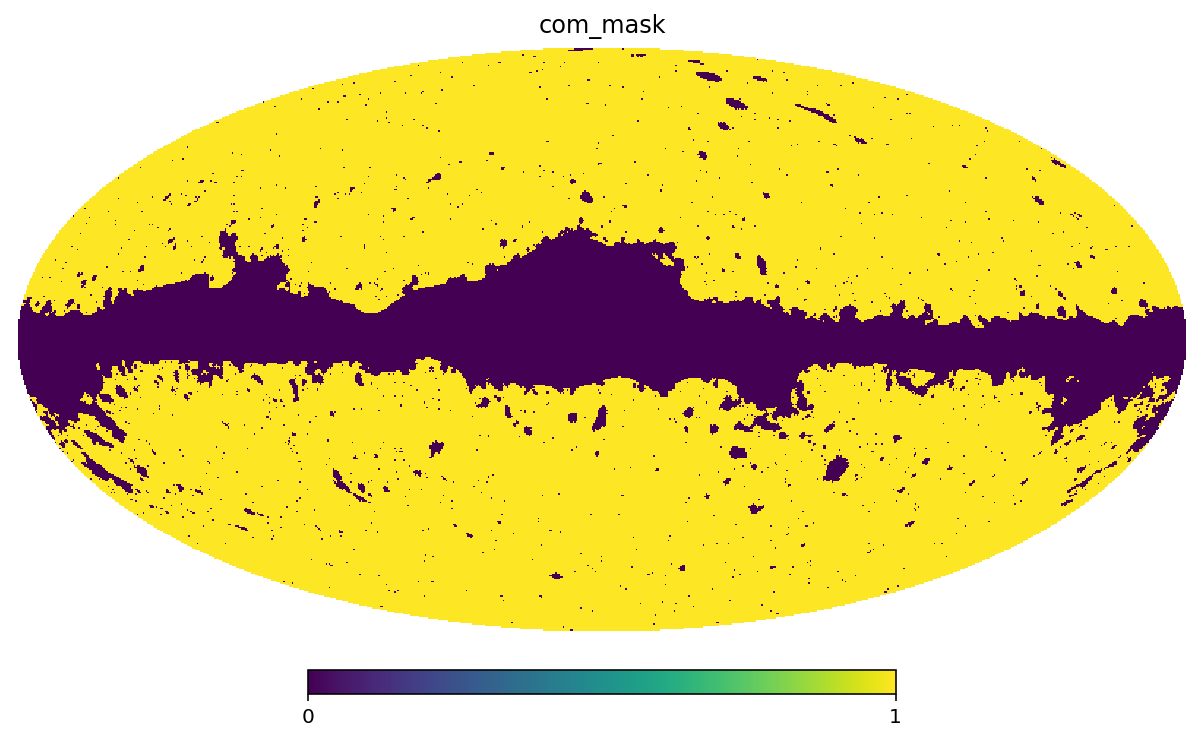

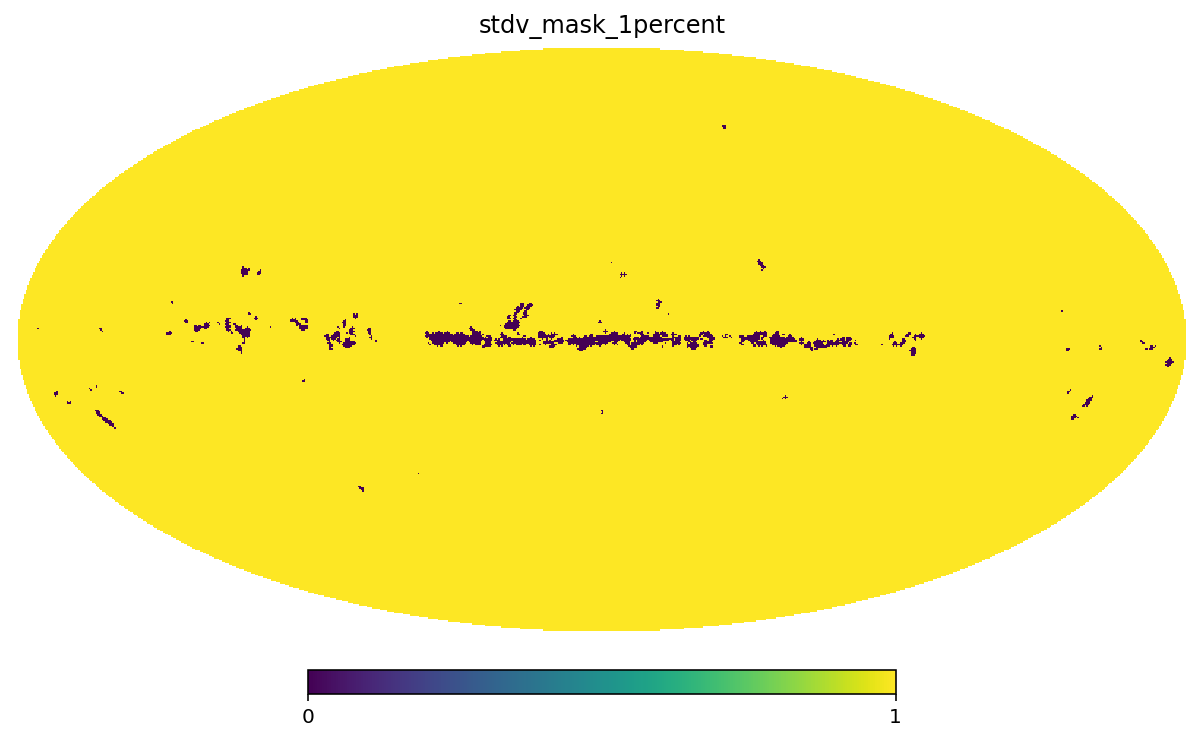

In [4]:
# Load masks
com_mask_hr = hp.read_map(mask_dir+com_name)
std_mask_hr = hp.read_map(mask_dir+std_name)
hp.mollview(com_mask_hr, title=com_label)
hp.mollview(std_mask_hr, title=std_label)

# Downgrade and smooth in the same way as maps
This gives mask values different from [0, 1].

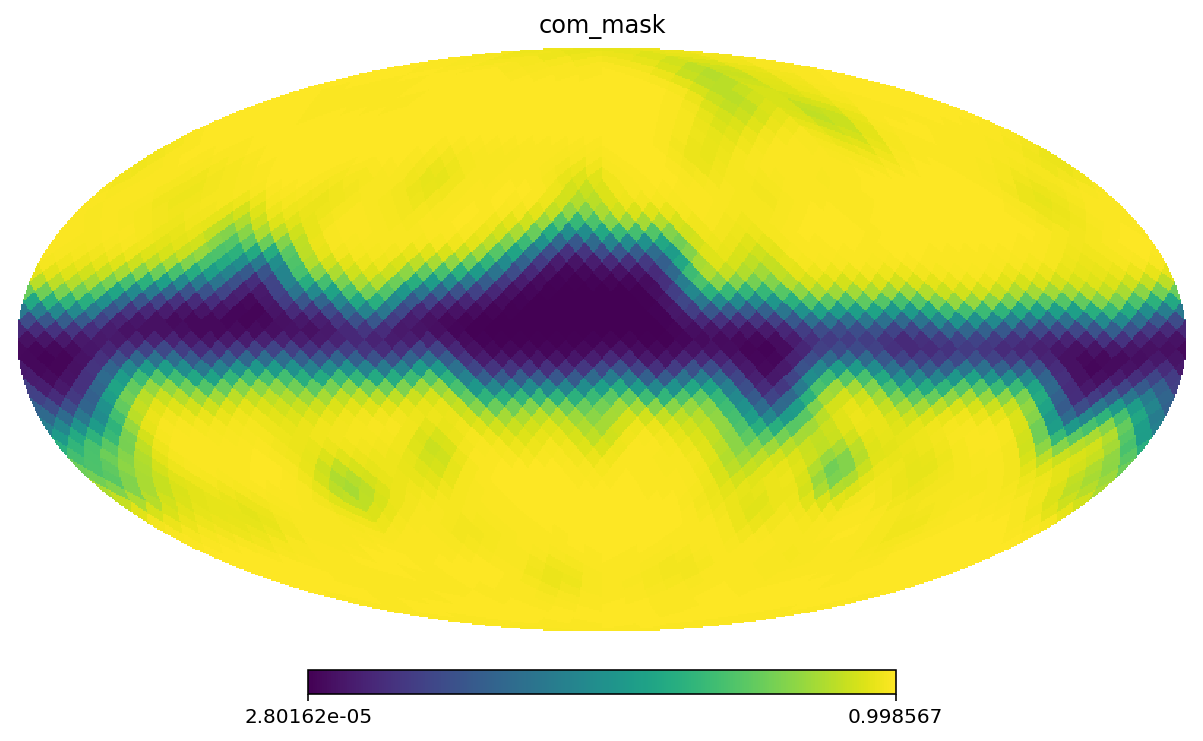

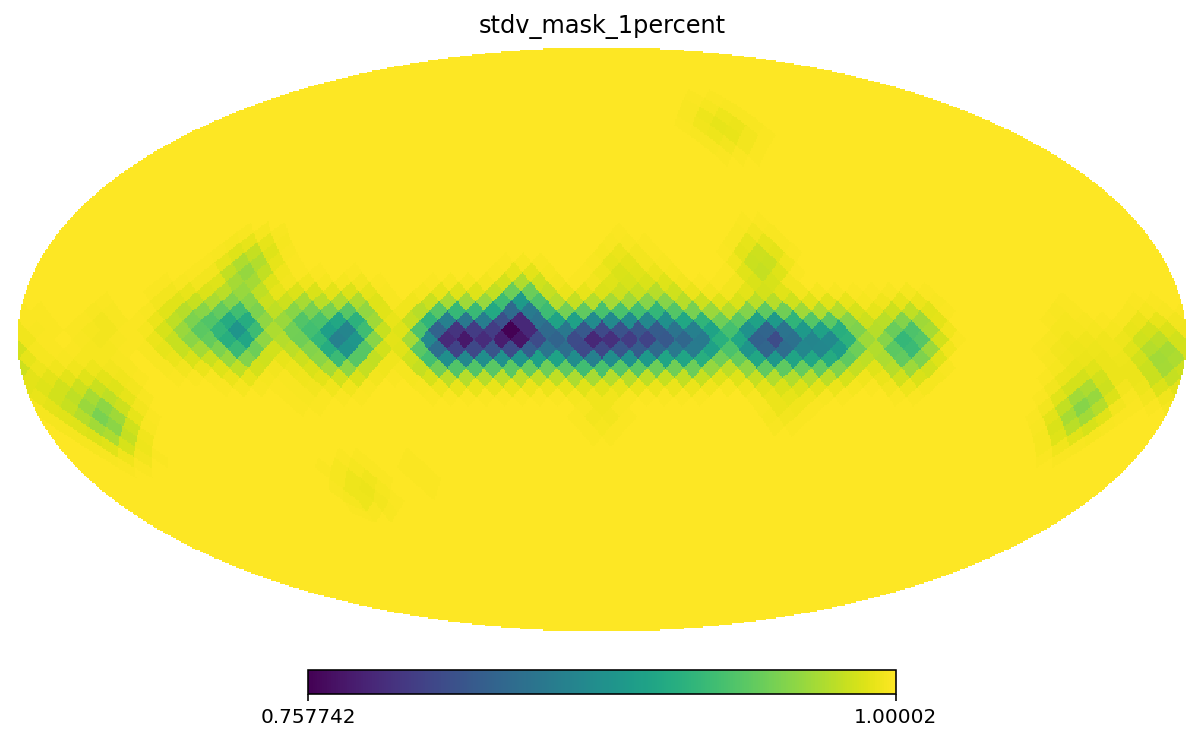

In [5]:
com_mask_lr = CMBanom.downgrade_map(com_mask_hr, Nside_out)
std_mask_lr = CMBanom.downgrade_map(std_mask_hr, Nside_out)
hp.mollview(com_mask_lr, title=com_label)
hp.mollview(std_mask_lr, title=std_label)

# Obtain binary mask
To recover a binary mask, we define a parent pixel as masked (pixel value 0) when a fraction of more than $10\%$ of sub-pixels are masked (i.e. below a pixel value of 0.9).

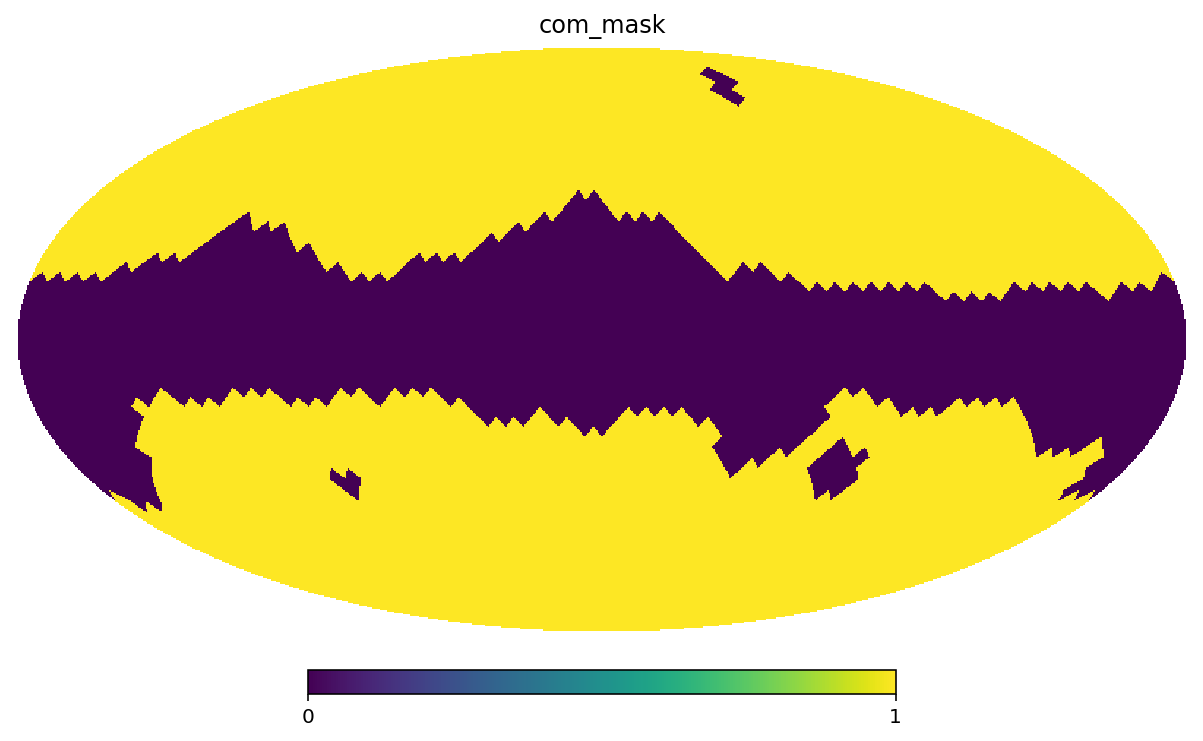

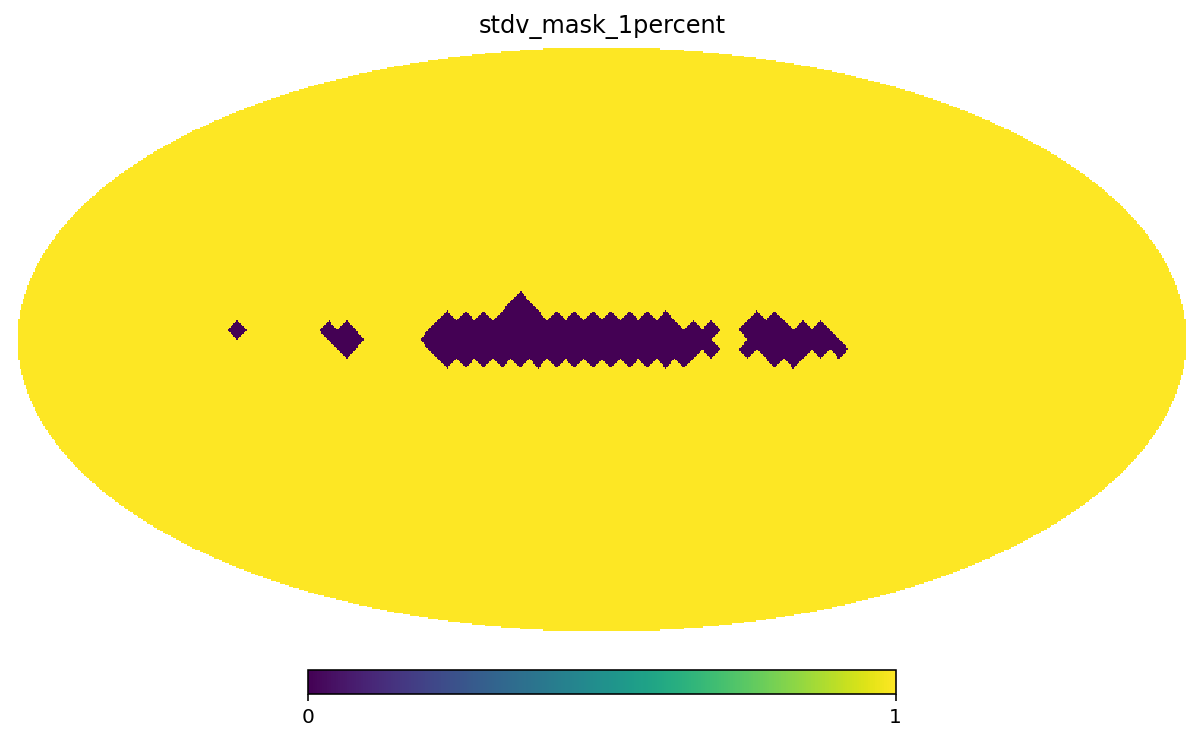

In [6]:
com_mask_bin = np.where(com_mask_lr > cutoff, 1, 0)
std_mask_bin = np.where(std_mask_lr > cutoff, 1, 0)
hp.mollview(com_mask_bin, title=com_label)
hp.mollview(std_mask_bin, title=std_label)

In [7]:
# Print sky fractions
print("Sky fractions:")
print(f"Common mask (Nside=2048): {100*len(np.nonzero(com_mask_hr)[0])/len(com_mask_hr):.1f} %")
print(f"Common mask (Nside={Nside_out}): {100*len(np.nonzero(com_mask_bin)[0])/len(com_mask_bin):.1f} %")
print(f"Std. mask (Nside=128): {100*len(np.nonzero(std_mask_hr)[0])/len(std_mask_hr):.1f} %")
print(f"Std. mask (Nside={Nside_out}): {100*len(np.nonzero(std_mask_bin)[0])/len(std_mask_bin):.1f} %")

Sky fractions:
Common mask (Nside=2048): 77.9 %
Common mask (Nside=16): 64.5 %
Std. mask (Nside=128): 99.0 %
Std. mask (Nside=16): 96.6 %


In [8]:
# Save downgraded binary masks
if save_mask: 
    hp.write_map(f"{mask_dir}{com_label}_cutoff_{cutoff}_nside_{Nside_out}.fits", com_mask_bin, overwrite=True, dtype=np.float64)
    if Nside_out < 128: hp.write_map(f"{mask_dir}{std_label}_cutoff_{cutoff}_nside_{Nside_out}.fits", std_mask_bin, overwrite=True, dtype=np.float64)
    

# Compute mask of northern ecliptic
For anomaly statistic "low northern variance", $\sigma_{16}$, at Nside = 16.

In [9]:
mask_south_ecl = np.append(np.ones(len(com_mask_lr)//2), np.zeros(len(com_mask_lr)//2))
rot_ec2gal     = hp.Rotator(coord="EG")
mask_south_ecl = rot_ec2gal.rotate_map_pixel(mask_south_ecl)
mask_south_ecl = np.where(mask_south_ecl > cutoff, 1, 0)

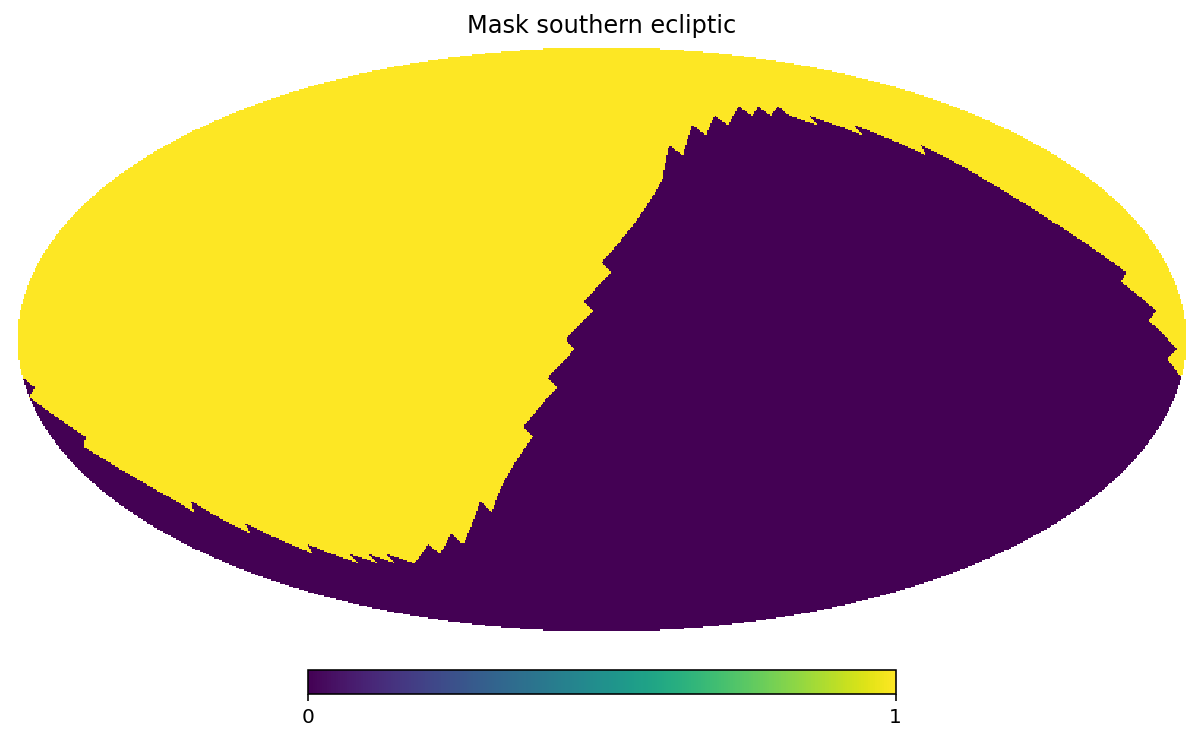

In [10]:
#Plot
hp.mollview(mask_south_ecl, title="Mask southern ecliptic")

In [11]:
# Print sky fractions
print("Sky fractions:")
print(f"Mask south ecliptic (Nside=128): {100*len(np.nonzero(mask_south_ecl)[0])/len(mask_south_ecl):.1f} %")

Sky fractions:
Mask south ecliptic (Nside=128): 49.2 %


In [12]:
# Save
if save_ecl_mask and Nside_out==16: 
    hp.write_map(f"{mask_dir}mask_south_ecl_nside_{Nside_out}.fits", mask_south_ecl, overwrite=True, dtype=np.float64)